In [16]:
# %%
import sys
sys.path.insert(0, "/Users/jackson/Library/CloudStorage/OneDrive-UniversityofTennessee/University of Tennessee/Talmy lab/MCMCwithODEs_primer-v0.1.0")
from utils.plot_utils_v2 import *

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
## Cell 1 -- Data loading ##

# G. hux, bacteria, EhV
df = pd.read_excel('data/AQUACOSM_VIMS-Ehux_CoreData-2.xlsx', usecols=['Taxonomic Group', 'Day', 'Bag 4'])
df.rename(columns={'Bag 4': 'Abundance'}, inplace=True)

# Zooplankton (ciliates)
ciliate = pd.read_csv("data/ciliates/Dataset 4.csv", header=None, names=['Day', 'Abundance'])
ciliate['Taxonomic Group'] = 'Ciliates'
ciliate['Abundance'] = ciliate['Abundance'] / 1000

result = pd.concat([df, ciliate])
result['Taxonomic Group'] = result['Taxonomic Group'].replace({'Neuks_HighSS': 'G. huxleyi'})
result = result.loc[result['Taxonomic Group'].isin(['G. huxleyi', 'Bacteria', 'EhV', 'Ciliates'])]

ghux     = result.loc[result['Taxonomic Group'] == 'G. huxleyi']
bacteria = result.loc[result['Taxonomic Group'] == 'Bacteria']
ehv      = result.loc[result['Taxonomic Group'] == 'EhV']

ehux_live_density = ghux['Abundance'].values
ehux_live_time    = ghux['Day'].values
log_ehux_live_density = np.log(ehux_live_density + 1e-9)

bacteria_density = bacteria['Abundance'].values
bacteria_time    = bacteria['Day'].values
log_bacteria_density = np.log(bacteria_density + 1e-9)

ehv_density = ehv['Abundance'].values
ehv_time    = ehv['Day'].values
log_ehv_density = np.log(ehv_density + 1e-9)

ciliate_density = ciliate['Abundance'].values
ciliate_time    = ciliate['Day'].values
log_ciliate_density = np.log(ciliate_density + 1e-9)

In [18]:
# %%
## Cell 2 -- ODE system (5 states: P, D, B, V, Z) ##

def general_case(t, y, params):
    P, D, B, V, Z = np.maximum(y, 0.0)
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, \
        beta_V, phi_V, Gmax, k_m, theta_Z = params

    phi_B = rho * D

    dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B - phi_V * P * V - Gmax * P / (k_m + P) * Z
    dDdt = delta_P * P + phi_B * P * B + phi_V * P * V - lambda_D * D
    dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
    dVdt = beta_V * phi_V * P * V
    dZdt = theta_Z * Gmax * P / (k_m + P) * Z

    return [dPdt, dDdt, dBdt, dVdt, dZdt]

In [19]:
# %%
## Cell 3 -- Robust PyTensor Op wrapping solve_ivp ##

import pytensor.tensor as pt
from pytensor.graph.op import Op
from scipy.integrate import solve_ivp

class SolveIVPWrapper(Op):
    itypes = [pt.dvector]   # theta + y0
    otypes = [pt.dvector]   # flattened: [P@ehux_times, B@bact_times, V@ehv_times, Z@ciliate_times]

    def __init__(self, t_grid, t_obs_list):
        self.t_grid = np.asarray(t_grid)
        self.t_obs_list = [np.asarray(t) for t in t_obs_list]
        self.lens = [len(t) for t in self.t_obs_list]

    def perform(self, node, inputs, outputs):
        theta_y0, = inputs
        theta = theta_y0[:13]
        y0 = theta_y0[13:]

        sol = None
        for method in ("LSODA", "BDF"):
            try:
                s = solve_ivp(fun=lambda t, y: general_case(t, y, theta),
                               t_span=(self.t_grid[0], self.t_grid[-1]),
                               y0=y0, t_eval=self.t_grid, method=method,
                               rtol=1e-6, atol=1e-9)
                if s.success and np.all(np.isfinite(s.y)):
                    sol = s
                    break
            except Exception:
                continue

        if sol is None:
            outputs[0][0] = np.full(sum(self.lens), 1e12)
            return

        states = np.maximum(sol.y, 1.0)

        preds = []
        for state_idx, t_obs in zip([0, 2, 3, 4], self.t_obs_list):  # P, B, V, Z columns
            preds.append(np.interp(t_obs, self.t_grid, states[state_idx]))
        outputs[0][0] = np.concatenate(preds)

In [ ]:
# %%
## Cell 5 -- Priors + likelihood ##

import pymc as pm

all_times = np.union1d(np.union1d(ehux_live_time, bacteria_time),
                        np.union1d(ehv_time, ciliate_time))
all_times = np.sort(np.unique(all_times))

ode_op = SolveIVPWrapper(all_times, [ehux_live_time, bacteria_time, ehv_time, ciliate_time])
n1, n2, n3, n4 = len(ehux_live_time), len(bacteria_time), len(ehv_time), len(ciliate_time)

def lognorm(name, centre, sigma=0.4):
    return pm.LogNormal(name, mu=np.log(centre), sigma=sigma)

with pm.Model() as model:
    mu_P     = lognorm('mu_P',     5.888e-1, 0.4)
    k_P      = lognorm('k_P',      7.762e+6, 0.4)
    delta_P  = lognorm('delta_P',  5.012e-2, 0.4)
    mu_B     = lognorm('mu_B',     5.012e-1, 0.4)
    k_B      = lognorm('k_B',      1.096e+7, 0.4)
    beta_B   = lognorm('beta_B',   2.512e+1, 0.4)
    rho      = lognorm('rho',      7.413e-14, 0.4)
    lambda_D = lognorm('lambda_D', 3.020e-1, 0.4)
    beta_V   = lognorm('beta_V',   1.778e+2, 0.4)
    phi_V    = lognorm('phi_V',    1.175e-8, 0.4)
    Gmax     = lognorm('Gmax',     6.918e-1, 0.4)
    k_m      = lognorm('k_m',      1.175e+1, 0.4)
    theta_Z  = lognorm('theta_Z',  1.514e-1, 0.4)

    # -- Initial conditions --
    P0       = lognorm('P0', 1.000e+2, 0.3)
    D0_ratio = lognorm('D0_ratio', 1.000e+0, 0.2)
    D0       = pm.Deterministic('D0', P0 * D0_ratio)
    B0       = lognorm('B0', 1.820e+5, 0.3)
    V0       = lognorm('V0', 2.692e+5, 0.3)
    Z0       = lognorm('Z0', 2.630e+1, 0.3)

    sigma_live     = 0.3 * np.log(10)
    sigma_bacteria = 0.3 * np.log(10)
    sigma_virus    = 0.3 * np.log(10)
    sigma_ciliate  = 0.3 * np.log(10)

    # sigma_live     = pm.HalfNormal('sigma_live', 1)
    # sigma_bacteria = pm.HalfNormal('sigma_bacteria', 1)
    # sigma_virus    = pm.HalfNormal('sigma_virus', 1)
    # sigma_ciliate  = pm.HalfNormal('sigma_ciliate', 1)

    preds = ode_op(pt.stack([mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D,
                              beta_V, phi_V, Gmax, k_m, theta_Z,
                              P0, D0, B0, V0, Z0]))

    live    = preds[:n1]
    bacteria_pred = preds[n1:n1+n2]
    virus    = preds[n1+n2:n1+n2+n3]
    ciliate_pred  = preds[n1+n2+n3:]

    pm.Normal("Y_live",     mu=pm.math.log(live),           sigma=sigma_live,     observed=log_ehux_live_density)
    pm.Normal("Y_bacteria", mu=pm.math.log(bacteria_pred),  sigma=sigma_bacteria, observed=log_bacteria_density)
    pm.Normal("Y_virus",    mu=pm.math.log(virus),          sigma=sigma_virus,    observed=log_ehv_density)
    pm.Normal("Y_ciliate",  mu=pm.math.log(ciliate_pred),   sigma=sigma_ciliate,  observed=log_ciliate_density)

Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, beta_V, phi_V, Gmax, k_m, theta_Z, P0, D0_ratio, B0, V0, Z0]


Output()

Sampling 4 chains for 15_000 tune and 30_000 draw iterations (60_000 + 120_000 draws total) took 236 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [B0, D0_ratio, Gmax, P0, V0, Y_bacteria, Y_ciliate, Y_live, Y_virus, Z0, beta_B, beta_V, delta_P, k_B, k_P, k_m, lambda_D, mu_B, mu_P, phi_V, rho, theta_Z]


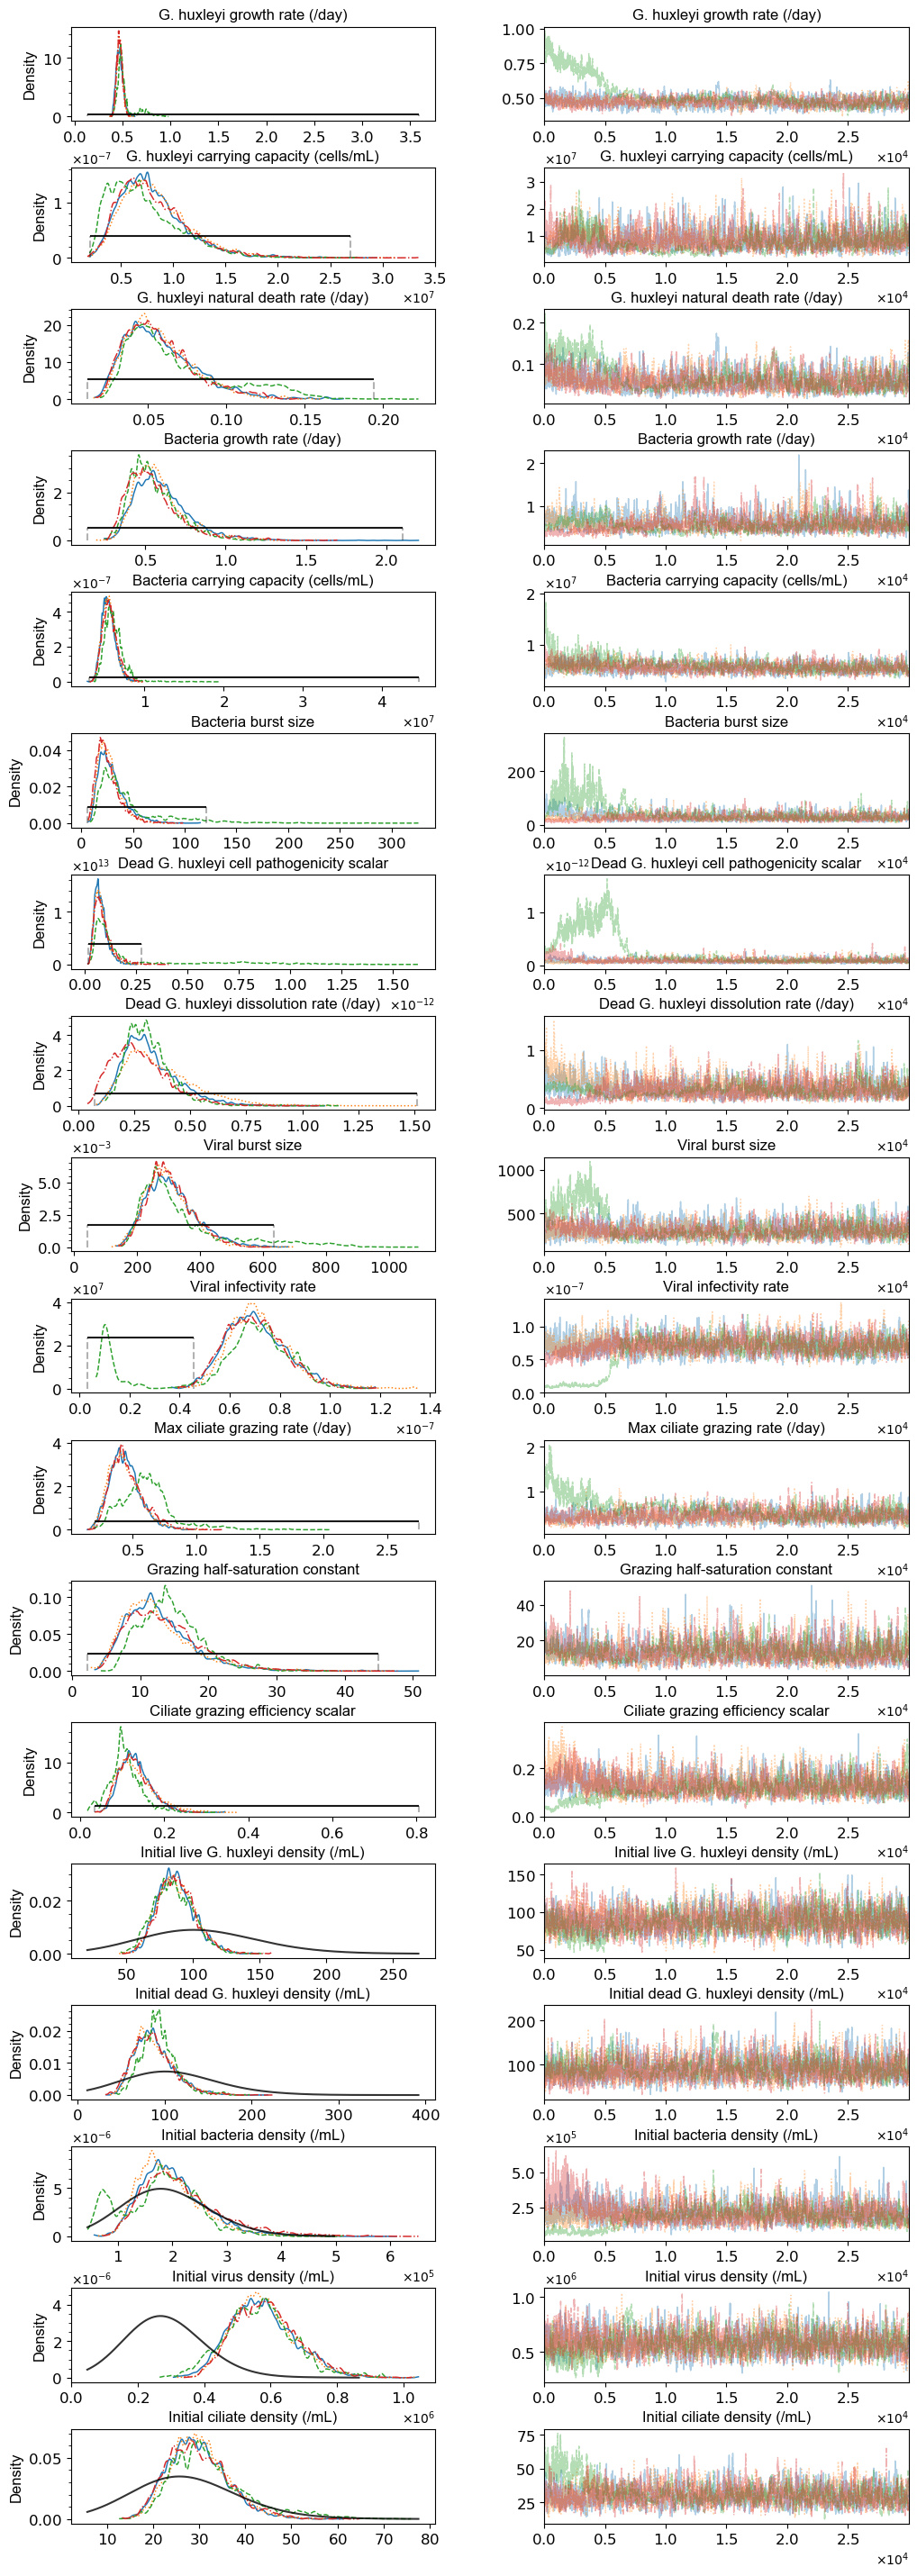

array([[<Axes: title={'center': 'G. huxleyi growth rate (/day)'}, ylabel='Density'>,
        <Axes: title={'center': 'G. huxleyi growth rate (/day)'}>],
       [<Axes: title={'center': 'G. huxleyi carrying capacity (cells/mL)'}, ylabel='Density'>,
        <Axes: title={'center': 'G. huxleyi carrying capacity (cells/mL)'}>],
       [<Axes: title={'center': 'G. huxleyi natural death rate (/day)'}, ylabel='Density'>,
        <Axes: title={'center': 'G. huxleyi natural death rate (/day)'}>],
       [<Axes: title={'center': 'Bacteria growth rate (/day)'}, ylabel='Density'>,
        <Axes: title={'center': 'Bacteria growth rate (/day)'}>],
       [<Axes: title={'center': 'Bacteria carrying capacity (cells/mL)'}, ylabel='Density'>,
        <Axes: title={'center': 'Bacteria carrying capacity (cells/mL)'}>],
       [<Axes: title={'center': 'Bacteria burst size'}, ylabel='Density'>,
        <Axes: title={'center': 'Bacteria burst size'}>],
       [<Axes: title={'center': 'Dead G. huxleyi cell pa

In [21]:
# %%
## Cell 6 -- Sampling ##

with model:
    trace = pm.sample(draws=30000,
                       tune=15000,
                       chains=4,
                       cores=4,
                       step=pm.DEMetropolisZ(),
                       return_inferencedata=True)

# %%
## Trace / posterior plots ##

plot_trace(trace=trace,
           model=model,
           uni=['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D',
                'beta_V', 'phi_V', 'Gmax', 'k_m', 'theta_Z'],
           fontname='Arial',
           fontsize=12,
           num_prior_samples=2000,
           var_names_map={
               'mu_P': 'G. huxleyi growth rate (/day)',
               'k_P': 'G. huxleyi carrying capacity (cells/mL)',
               'delta_P': 'G. huxleyi natural death rate (/day)',
               'mu_B': 'Bacteria growth rate (/day)',
               'k_B': 'Bacteria carrying capacity (cells/mL)',
               'beta_B': 'Bacteria burst size',
               'rho': 'Dead G. huxleyi cell pathogenicity scalar',
               'lambda_D': 'Dead G. huxleyi dissolution rate (/day)',
               'beta_V': 'Viral burst size',
               'phi_V': 'Viral infectivity rate',
               'Gmax': 'Max ciliate grazing rate (/day)',
               'k_m': 'Grazing half-saturation constant',
               'theta_Z': 'Ciliate grazing efficiency scalar',
               'P0': 'Initial live G. huxleyi density (/mL)',
               'D0': 'Initial dead G. huxleyi density (/mL)',
               'B0': 'Initial bacteria density (/mL)',
               'V0': 'Initial virus density (/mL)',
               'Z0': 'Initial ciliate density (/mL)',
               'sigma_live': 'σ for live cells',
               'sigma_bacteria': 'σ for bacteria',
               'sigma_virus': 'σ for virus',
               'sigma_ciliate': 'σ for ciliates',
           },
           var_order=['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D',
                      'beta_V', 'phi_V', 'Gmax', 'k_m', 'theta_Z',
                      'P0', 'D0', 'B0', 'V0', 'Z0',
                      'sigma_live', 'sigma_bacteria', 'sigma_virus', 'sigma_ciliate'],
           save_path='figures/eco_general_chains_reparam.png')


## Posterior spaghetti + confidence band plotting

In [10]:
from scipy.integrate import solve_ivp
from matplotlib.collections import LineCollection

KINETIC_NAMES = ['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D',
                  'beta_V', 'phi_V', 'Gmax', 'k_m', 'theta_Z']
IC_NAMES      = ['P0', 'D0', 'B0', 'V0', 'Z0']

def _posterior_1d(trace, name):
    post = trace.posterior.stack(draws=("chain", "draw"))
    return np.asarray(post[name].values).reshape(-1)

def _run_one_draw(theta, y0, t_eval, method_list=("LSODA", "BDF")):
    for method in method_list:
        try:
            sol = solve_ivp(fun=lambda t, y: general_case(t, y, theta),
                             t_span=(t_eval[0], t_eval[-1]), y0=y0, t_eval=t_eval,
                             method=method, rtol=1e-6, atol=1e-9)
            if sol.success and np.all(np.isfinite(sol.y)):
                return np.maximum(sol.y, 1.0)
        except Exception:
            continue
    return None

def _sample_draws(trace, n_samples, burn_in, seed):
    all_names = KINETIC_NAMES + IC_NAMES
    vals = {n: _posterior_1d(trace, n) for n in all_names}
    n_avail = len(vals['mu_P'])
    assert burn_in + n_samples <= n_avail, "Not enough posterior samples"
    rng = np.random.default_rng(seed)
    idxs = rng.choice(np.arange(burn_in, n_avail), size=n_samples, replace=False)
    return vals, idxs

OBS_PANELS = [
    ('P', 'Total G. huxleyi (/mL)', ehux_live_time, ehux_live_density),
    ('B', 'Bacteria (/mL)',          bacteria_time,   bacteria_density),
    ('V', 'Virus (/mL)',             ehv_time,        ehv_density),
    ('Z', 'Ciliates (/mL)',          ciliate_time,    ciliate_density),
]
STATE_COL = {'P': 0, 'D': 1, 'B': 2, 'V': 3, 'Z': 4}

def eco_posterior_spaghetti(trace, n_samples=300, burn_in=0, seed=42,
                             n_grid=200, alpha=0.04, save_path=None):
    t_eval = np.linspace(0, max(ehux_live_time.max(), bacteria_time.max(),
                                  ehv_time.max(), ciliate_time.max()), n_grid)
    vals, idxs = _sample_draws(trace, n_samples, burn_in, seed)

    segments = {k: [] for k, *_ in OBS_PANELS}
    for i in idxs:
        theta = [vals[n][i] for n in KINETIC_NAMES]
        y0    = [vals[n][i] for n in IC_NAMES]
        states = _run_one_draw(theta, y0, t_eval)
        if states is None:
            continue
        for key, *_ in OBS_PANELS:
            segments[key].append(np.column_stack((t_eval, states[STATE_COL[key]]))[:, None, :])

    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharex=True)
    for ax, (key, label, t_obs, v_obs) in zip(axes, OBS_PANELS):
        if segments[key]:
            arr = np.concatenate(segments[key], axis=1).transpose(1, 0, 2)
            ax.add_collection(LineCollection(arr, linewidths=1.0, alpha=alpha, color='C0'))
            ax.autoscale_view()
        ax.scatter(t_obs, v_obs, color='black', s=15, zorder=5)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Time (days)')
        ax.set_yscale('log')
    axes[0].set_ylabel('Abundance')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def eco_posterior_bands(trace, n_samples=200, burn_in=0, seed=42,
                         n_grid=200, lo=5, hi=95, save_path=None):
    t_eval = np.linspace(0, max(ehux_live_time.max(), bacteria_time.max(),
                                  ehv_time.max(), ciliate_time.max()), n_grid)
    vals, idxs = _sample_draws(trace, n_samples, burn_in, seed)

    curves = {k: [] for k, *_ in OBS_PANELS}
    for i in idxs:
        theta = [vals[n][i] for n in KINETIC_NAMES]
        y0    = [vals[n][i] for n in IC_NAMES]
        states = _run_one_draw(theta, y0, t_eval)
        if states is None:
            continue
        for key, *_ in OBS_PANELS:
            curves[key].append(states[STATE_COL[key]])

    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharex=True)
    for ax, (key, label, t_obs, v_obs) in zip(axes, OBS_PANELS):
        if curves[key]:
            arr = np.array(curves[key])
            p_lo, p_med, p_hi = np.percentile(arr, [lo, 50, hi], axis=0)
            ax.fill_between(t_eval, p_lo, p_hi, alpha=0.25, color='C0', label=f'{lo}-{hi}% CI')
            ax.plot(t_eval, p_med, color='C0', lw=2, label='Median')
        ax.scatter(t_obs, v_obs, color='black', s=15, zorder=5, label='Observed')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Time (days)')
        ax.set_yscale('log')
        ax.legend(fontsize=7, frameon=False)
    axes[0].set_ylabel('Abundance')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# %%
## ACTUALLY CALL the plotting functions (previously defined but never invoked) ##

eco_posterior_spaghetti(trace, n_samples=300, save_path='figures/eco_spaghetti.png')
eco_posterior_bands(trace, n_samples=200, save_path='figures/eco_bands.png')

# %%
## Convergence diagnostics ##

import arviz as az
print(az.summary(trace, var_names=['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B',
                                     'rho', 'lambda_D', 'beta_V', 'phi_V', 'Gmax', 'k_m', 'theta_Z']))
print(az.summary(trace, var_names=['rho', 'phi_V'], round_to=20))

NameError: name 'ehux_live_time' is not defined

Params from co-culture MCMC
  mu_P         7.918218e-01
  k_P          5.382034e+06
  delta_P      5.294857e-02
  mu_B         8.503184e-01
  k_B          1.022709e+08
  beta_B       3.384754e+00
  rho          5.113946e-15
  lambda_D     3.409695e-01
  P0           2.995223e+05
  D0           3.554064e+04
  B0           1.409821e+05

## Manual Ecosystem Parameter Explorer

In [23]:
from ipywidgets import FloatLogSlider, VBox, Accordion, Output, HTML
from IPython.display import display, clear_output

SLIDER_STYLE  = {'description_width': '110px'}
SLIDER_LAYOUT = {'width': '420px'}

def log_slider(val, lo, hi, desc):
    return FloatLogSlider(value=val, base=10, min=lo, max=hi, step=0.01,
                          description=desc, style=SLIDER_STYLE, layout=SLIDER_LAYOUT,
                          continuous_update=True, readout_format='.3e')

sl_mu_P     = log_slider(1.0,   -1,  1, 'mu_P')
sl_k_P      = log_slider(2e7,   5,  8, 'k_P')
sl_delta_P  = log_slider(0.05,  -3, -1, 'delta_P')
sl_mu_B     = log_slider(0.5,   -1,  0, 'mu_B')
sl_k_B      = log_slider(2e8,   6,  9, 'k_B')
sl_beta_B   = log_slider(25,    -1,  2, 'beta_B')
sl_rho      = log_slider(5e-14,-15,-13, 'rho')
sl_lambda_D = log_slider(0.3,   -1,  0, 'lambda_D')
sl_beta_V   = log_slider(350,    2,  3, 'beta_V')
sl_phi_V    = log_slider(2.5e-8,-8, -7, 'phi_V')
sl_Gmax     = log_slider(1.1,   -1,  1, 'Gmax')
sl_k_m      = log_slider(12,     0,  2, 'k_m')
sl_theta_Z  = log_slider(0.15,  -2,  0, 'theta_Z')

sl_P0 = log_slider(1e2, 0, 6, 'P0')
sl_B0 = log_slider(3e5, 0, 7, 'B0')
sl_V0 = log_slider(3e6, 0, 8, 'V0')
sl_Z0 = log_slider(5e1, -1, 4, 'Z0')
sl_D0_ratio = log_slider(1.0, -1, 1, 'D0 / P0 ratio')

sliders = [sl_mu_P, sl_k_P, sl_delta_P, sl_mu_B, sl_k_B, sl_beta_B, sl_rho, sl_lambda_D,
           sl_beta_V, sl_phi_V, sl_Gmax, sl_k_m, sl_theta_Z,
           sl_P0, sl_B0, sl_V0, sl_Z0, sl_D0_ratio]

accordion = Accordion(children=[VBox(sliders)])
accordion.set_title(0, 'Ecosystem parameters')
out = Output()

_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
PANEL_CFG_MANUAL = [
    ('P', r'$\it{G. huxleyi}$', ehux_live_time, ehux_live_density, _cycle[0]),
    ('B', 'Bacteria',           bacteria_time,   bacteria_density,   _cycle[1]),
    ('V', 'Virus',              ehv_time,        ehv_density,        _cycle[2]),
    ('Z', 'Zooplankton',        ciliate_time,    ciliate_density,    _cycle[3]),
]

def build_manual_theta_y0():
    theta = [sl_mu_P.value, sl_k_P.value, sl_delta_P.value, sl_mu_B.value, sl_k_B.value,
             sl_beta_B.value, sl_rho.value, sl_lambda_D.value, sl_beta_V.value,
             sl_phi_V.value, sl_Gmax.value, sl_k_m.value, sl_theta_Z.value]
    P0 = sl_P0.value
    y0 = [P0, P0 * sl_D0_ratio.value, sl_B0.value, sl_V0.value, sl_Z0.value]
    return theta, y0

def run_ode_manual(theta, y0, t_out):
    t_eval = np.unique(t_out)
    t_span = (float(t_eval.min()), float(t_eval.max()))
    for method in ("LSODA", "BDF"):
        try:
            sol = solve_ivp(fun=lambda t, y: general_case(t, y, theta),
                             t_span=t_span, y0=y0, t_eval=t_eval, method=method,
                             rtol=1e-6, atol=1e-9)
            if sol.success and np.all(np.isfinite(sol.y)):
                states = np.maximum(sol.y, 1.0)
                interp = lambda row: np.interp(t_out, t_eval, row)
                return {'P': interp(states[0]), 'B': interp(states[2]),
                        'V': interp(states[3]), 'Z': interp(states[4])}
        except Exception:
            continue
    return None

t_dense_manual = np.linspace(0, max(ehux_live_time.max(), bacteria_time.max(),
                                     ehv_time.max(), ciliate_time.max()), 300)

def update_manual_plot(_=None):
    theta, y0 = build_manual_theta_y0()
    res = run_ode_manual(theta, y0, t_dense_manual)

    score = None
    if res is not None:
        all_t = np.concatenate([ehux_live_time, bacteria_time, ehv_time, ciliate_time])
        t_union = np.unique(all_t)
        res_u = run_ode_manual(theta, y0, t_union)
        score = 0.0
        for key, t_obs, v_obs in [('P', ehux_live_time, ehux_live_density),
                                   ('B', bacteria_time, bacteria_density),
                                   ('V', ehv_time, ehv_density),
                                   ('Z', ciliate_time, ciliate_density)]:
            if len(t_obs):
                pred = np.interp(t_obs, t_union, res_u[key])
                score += np.sum((np.log10(v_obs + 1e-9) - np.log10(pred + 1e-9)) ** 2)

    with out:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
        for ax, (key, label, t_obs, v_obs, color) in zip(axes, PANEL_CFG_MANUAL):
            if res is not None:
                ax.plot(t_dense_manual, res[key], color=color, lw=2)
                ax.set_yscale('log')
            ax.scatter(t_obs, v_obs, color='black', s=15, zorder=5)
            ax.set_xlabel('Time (days)')
            ax.set_title(label, fontsize=9)
        axes[0].set_ylabel('Abundance')

        score_str = f'{score:.2f}' if score is not None else 'ODE failed'
        fig.suptitle(f'Sum of squared log10-residuals: {score_str}', fontsize=11, y=1.03)
        plt.tight_layout()
        plt.show()

for sl in sliders:
    sl.observe(update_manual_plot, names='value')

display(HTML('<h3>Manual Ecosystem Model Explorer</h3>'), accordion, out)
update_manual_plot()

HTML(value='<h3>Manual Ecosystem Model Explorer</h3>')

Accordion(children=(VBox(children=(FloatLogSlider(value=1.0, description='mu_P', layout=Layout(width='420px'),…

Output()

# MCMC_whole_env — Per-Bag Mesocosm Fitting + Death Fractionation

Loops the single-bag (Bag 4) MCMC pipeline over all 8 AQUACOSM bags
(Light: 1-4, Dark: 5-7, Control/Fjord: 8), fits the 5-state ecosystem
model to each bag's data independently, then extends each bag's
best-fit (posterior-median) parameters into the 9-state death-tracking
ODE (P, D, B, V, Z, D_nat, D_bact, D_vir, D_zoop) -- same bookkeeping
pattern as `ecosystem_experiment.py` -- to quantify and plot each
bag's death signature (natural / bacterial / viral / grazing fractions).

ASSUMPTIONS -- please confirm/correct before trusting the output:
  1. Excel columns are named 'Bag 1' ... 'Bag 7', and bag 8 (Fjord/control)
     is under column 'Fjord' (see BAG_COLUMN_OVERRIDE below) -- adjust if
     the real column name differs.
  2. Ciliate CSVs follow 'data/ciliates/Dataset {bag_id}.csv', mirroring
     the Bag-4 example ('Dataset 4.csv') -- adjust BAG_CILIATE_FILE if
     the real files are named differently per bag.
  3. sigma_live/bacteria/virus/ciliate are FIXED (0.3*ln(10)), not
     sampled -- carried over from the co-culture fix earlier in this
     project, since free sigma let the sampler inflate noise instead of
     forcing a tight ODE fit. Set FIT_SIGMA=True below to revert to the
     free-sigma template you pasted.

In [1]:
import sys
sys.path.insert(0, "/Users/jackson/Library/CloudStorage/OneDrive-UniversityofTennessee/University of Tennessee/Talmy lab/MCMCwithODEs_primer-v0.1.0")
from utils.plot_utils_v2 import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytensor.tensor as pt
from pytensor.graph.op import Op
from scipy.integrate import solve_ivp
import pymc as pm
import json
import os

XLSX_PATH = 'data/AQUACOSM_VIMS-Ehux_CoreData-2.xlsx'

BAG_IDS = [1, 2, 3, 4, 5, 6, 7, 8]
BAG_TREATMENT = {1: 'Light', 2: 'Light', 3: 'Light', 4: 'Light',
                  5: 'Dark', 6: 'Dark', 7: 'Dark',
                  8: 'Control'}
BAG_COLUMN_OVERRIDE = {8: 'Fjord'}   # bag 8 -- adjust if the xlsx column is actually 'Bag 8'
BAG_CILIATE_FILE = {b: f'data/ciliates/Dataset {b}.csv' for b in BAG_IDS}  # verify per-bag filenames

FIT_SIGMA = False                      # False -> fixed sigma (recommended); True -> template's free HalfNormal
SIGMA_FIXED = 0.3 * np.log(10)         # ~0.6908, natural-log equiv. of old log10-scale sigma=0.3

DRAWS, TUNE, CHAINS, CORES = 20000, 8000, 4, 4   # trim vs. template's 30k/15k if 8 bags is slow; bump up later


In [2]:
## Cell 1 -- per-bag data loader ##

def load_bag_data(bag_id):
    col = BAG_COLUMN_OVERRIDE.get(bag_id, f'Bag {bag_id}')
    df = pd.read_excel(XLSX_PATH, usecols=['Taxonomic Group', 'Day', col])
    df = df.rename(columns={col: 'Abundance'})

    ciliate = pd.read_csv(BAG_CILIATE_FILE[bag_id], header=None, names=['Day', 'Abundance'])
    ciliate['Taxonomic Group'] = 'Ciliates'
    ciliate['Abundance'] = ciliate['Abundance'] / 1000

    result = pd.concat([df, ciliate])
    result['Taxonomic Group'] = result['Taxonomic Group'].replace({'Neuks_HighSS': 'G. huxleyi'})
    result = result.loc[result['Taxonomic Group'].isin(['G. huxleyi', 'Bacteria', 'EhV', 'Ciliates'])]

    ghux     = result.loc[result['Taxonomic Group'] == 'G. huxleyi']
    bacteria = result.loc[result['Taxonomic Group'] == 'Bacteria']
    ehv      = result.loc[result['Taxonomic Group'] == 'EhV']

    return {
        'ehux_live_time':     ghux['Day'].values.astype(float),
        'ehux_live_density':  ghux['Abundance'].values.astype(float),
        'bacteria_time':      bacteria['Day'].values.astype(float),
        'bacteria_density':   bacteria['Abundance'].values.astype(float),
        'ehv_time':           ehv['Day'].values.astype(float),
        'ehv_density':        ehv['Abundance'].values.astype(float),
        'ciliate_time':       ciliate['Day'].values.astype(float),
        'ciliate_density':    ciliate['Abundance'].values.astype(float),
    }

In [3]:
## Cell 2 -- ODE systems ##
# Fitting model: 5 states (P, D, B, V, Z) -- lumped D drives phi_B, matches
# the Op's likelihood streams exactly. Used only inside SolveIVPWrapper.

def general_case(t, y, params):
    P, D, B, V, Z = np.maximum(y, 0.0)
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, \
        beta_V, phi_V, Gmax, k_m, theta_Z = params

    phi_B = rho * D
    graz  = Gmax * P / (k_m + P) * Z

    dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B - phi_V * P * V - graz
    dDdt = delta_P * P + phi_B * P * B + phi_V * P * V - lambda_D * D
    dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
    dVdt = beta_V * phi_V * P * V
    dZdt = theta_Z * graz

    return [dPdt, dDdt, dBdt, dVdt, dZdt]


# Death-fractionation model: 9 states -- same core dynamics as above, PLUS
# four bookkeeping accumulators (D_nat/D_bact/D_vir/D_zoop) that track WHICH
# pathway killed each cell. No feedback into P/D/B/V/Z -- purely for
# post-fit death-signature analysis, run once per bag using that bag's
# posterior-median params (mirrors ecosystem_experiment.py exactly).

def general_case_death_track(t, y, params):
    P, D, B, V, Z, D_nat, D_bact, D_vir, D_zoop = np.maximum(y, 0.0)
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, \
        beta_V, phi_V, Gmax, k_m, theta_Z = params

    phi_B = rho * D
    graz  = Gmax * P / (k_m + P) * Z

    dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B - phi_V * P * V - graz
    dDdt = delta_P * P + phi_B * P * B + phi_V * P * V - lambda_D * D
    dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
    dVdt = beta_V * phi_V * P * V
    dZdt = theta_Z * graz

    dD_nat  = delta_P * P    - lambda_D * D_nat
    dD_bact = phi_B * P * B  - lambda_D * D_bact
    dD_vir  = phi_V * P * V  - lambda_D * D_vir
    dD_zoop = graz           - lambda_D * D_zoop   # full grazing loss, not theta_Z-scaled

    return [dPdt, dDdt, dBdt, dVdt, dZdt, dD_nat, dD_bact, dD_vir, dD_zoop]


In [4]:
# Cell 3 -- Robust PyTensor Op (LSODA -> BDF fallback, penalize on failure) ##

class SolveIVPWrapper(Op):
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, t_grid, t_obs_list):
        self.t_grid = np.asarray(t_grid)
        self.t_obs_list = [np.asarray(t) for t in t_obs_list]
        self.lens = [len(t) for t in self.t_obs_list]

    def perform(self, node, inputs, outputs):
        theta_y0, = inputs
        theta = theta_y0[:13]
        y0 = theta_y0[13:]

        sol = None
        for method in ("LSODA", "BDF"):
            try:
                s = solve_ivp(fun=lambda t, y: general_case(t, y, theta),
                               t_span=(self.t_grid[0], self.t_grid[-1]),
                               y0=y0, t_eval=self.t_grid, method=method,
                               rtol=1e-6, atol=1e-9)
                if s.success and np.all(np.isfinite(s.y)):
                    sol = s
                    break
            except Exception:
                continue

        if sol is None:
            outputs[0][0] = np.full(sum(self.lens), 1e12)
            return

        states = np.maximum(sol.y, 1.0)
        preds = []
        for state_idx, t_obs in zip([0, 2, 3, 4], self.t_obs_list):  # P, B, V, Z columns
            preds.append(np.interp(t_obs, self.t_grid, states[state_idx]))
        outputs[0][0] = np.concatenate(preds)


In [5]:
## Cell 4 -- priors (same centers/sigmas as the pasted template) ##

def lognorm(name, centre, sigma=0.4):
    return pm.LogNormal(name, mu=np.log(centre), sigma=sigma)

KINETIC_NAMES = ['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D',
                  'beta_V', 'phi_V', 'Gmax', 'k_m', 'theta_Z']
IC_NAMES = ['P0', 'D0', 'B0', 'V0', 'Z0']

def build_and_fit_bag(bag_id, data, sample_kwargs):
    ehux_live_time,    ehux_live_density    = data['ehux_live_time'],    data['ehux_live_density']
    bacteria_time,     bacteria_density     = data['bacteria_time'],     data['bacteria_density']
    ehv_time,          ehv_density          = data['ehv_time'],          data['ehv_density']
    ciliate_time,      ciliate_density      = data['ciliate_time'],      data['ciliate_density']

    log_ehux_live_density = np.log(ehux_live_density + 1e-9)
    log_bacteria_density  = np.log(bacteria_density + 1e-9)
    log_ehv_density       = np.log(ehv_density + 1e-9)
    log_ciliate_density   = np.log(ciliate_density + 1e-9)

    all_times = np.union1d(np.union1d(ehux_live_time, bacteria_time),
                            np.union1d(ehv_time, ciliate_time))
    all_times = np.sort(np.unique(all_times))

    ode_op = SolveIVPWrapper(all_times, [ehux_live_time, bacteria_time, ehv_time, ciliate_time])
    n1, n2, n3, n4 = len(ehux_live_time), len(bacteria_time), len(ehv_time), len(ciliate_time)

    with pm.Model() as model:
        mu_P     = lognorm('mu_P',     5.888e-1, 0.4)
        k_P      = lognorm('k_P',      7.762e+6, 0.4)
        delta_P  = lognorm('delta_P',  5.012e-2, 0.4)
        mu_B     = lognorm('mu_B',     5.012e-1, 0.4)
        k_B      = lognorm('k_B',      1.096e+7, 0.4)
        beta_B   = lognorm('beta_B',   2.512e+1, 0.4)
        rho      = lognorm('rho',      7.413e-14, 0.4)
        lambda_D = lognorm('lambda_D', 3.020e-1, 0.4)
        beta_V   = lognorm('beta_V',   1.778e+2, 0.4)
        phi_V    = lognorm('phi_V',    1.175e-8, 0.4)
        Gmax     = lognorm('Gmax',     6.918e-1, 0.4)
        k_m      = lognorm('k_m',      1.175e+1, 0.4)
        theta_Z  = lognorm('theta_Z',  1.514e-1, 0.4)

        P0       = lognorm('P0', 1.000e+2, 0.3)
        D0_ratio = lognorm('D0_ratio', 1.000e+0, 0.2)
        D0       = pm.Deterministic('D0', P0 * D0_ratio)
        B0       = lognorm('B0', 1.820e+5, 0.3)
        V0       = lognorm('V0', 2.692e+5, 0.3)
        Z0       = lognorm('Z0', 2.630e+1, 0.3)

        if FIT_SIGMA:
            sigma_live     = pm.HalfNormal('sigma_live', 1)
            sigma_bacteria = pm.HalfNormal('sigma_bacteria', 1)
            sigma_virus    = pm.HalfNormal('sigma_virus', 1)
            sigma_ciliate  = pm.HalfNormal('sigma_ciliate', 1)
        else:
            sigma_live = sigma_bacteria = sigma_virus = sigma_ciliate = SIGMA_FIXED

        preds = ode_op(pt.stack([mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D,
                                  beta_V, phi_V, Gmax, k_m, theta_Z,
                                  P0, D0, B0, V0, Z0]))

        live          = preds[:n1]
        bacteria_pred = preds[n1:n1+n2]
        virus         = preds[n1+n2:n1+n2+n3]
        ciliate_pred  = preds[n1+n2+n3:]

        pm.Normal("Y_live",     mu=pm.math.log(live),          sigma=sigma_live,     observed=log_ehux_live_density)
        pm.Normal("Y_bacteria", mu=pm.math.log(bacteria_pred), sigma=sigma_bacteria, observed=log_bacteria_density)
        pm.Normal("Y_virus",    mu=pm.math.log(virus),         sigma=sigma_virus,    observed=log_ehv_density)
        pm.Normal("Y_ciliate",  mu=pm.math.log(ciliate_pred),  sigma=sigma_ciliate,  observed=log_ciliate_density)

        trace = pm.sample(step=pm.DEMetropolisZ(), return_inferencedata=True, **sample_kwargs)

    return model, trace

In [6]:
## Cell 5 -- death-fractionation from best-fit (posterior-median) params ##

def death_fractionation(median_params, t_max, n_grid=300):
    theta = [median_params[n] for n in KINETIC_NAMES]
    y0_5state = [median_params['P0'], median_params['D0'], median_params['B0'],
                 median_params['V0'], median_params['Z0']]
    # D_nat/D_bact/D_vir/D_zoop start at 0 except D_nat, which absorbs the
    # initial lumped D0 (no historical attribution available at t=0 --
    # same convention used in ecosystem_experiment.py)
    y0_9state = y0_5state + [median_params['D0'], 0.0, 0.0, 0.0]

    t_eval = np.linspace(0, t_max, n_grid)
    sol = None
    for method in ("LSODA", "BDF"):
        try:
            s = solve_ivp(fun=lambda t, y: general_case_death_track(t, y, theta),
                           t_span=(0, t_max), y0=y0_9state, t_eval=t_eval,
                           method=method, rtol=1e-6, atol=1e-9)
            if s.success and np.all(np.isfinite(s.y)):
                sol = s
                break
        except Exception:
            continue
    if sol is None:
        return None

    P, D, B, V, Z, D_nat, D_bact, D_vir, D_zoop = np.maximum(sol.y, 0.0)

    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, \
        beta_V, phi_V, Gmax, k_m, theta_Z = theta
    phi_B = rho * D
    graz  = Gmax * P / (k_m + P) * Z

    flux_nat  = delta_P * P
    flux_bact = phi_B * P * B
    flux_vir  = phi_V * P * V
    flux_zoop = graz
    total_sum = flux_nat.sum() + flux_bact.sum() + flux_vir.sum() + flux_zoop.sum() + 1e-30

    fractions = {
        'Natural':   float(flux_nat.sum() / total_sum),
        'Bacterial': float(flux_bact.sum() / total_sum),
        'Viral':     float(flux_vir.sum() / total_sum),
        'Grazing':   float(flux_zoop.sum() / total_sum),
    }
    curves = {'t': t_eval, 'D_nat': D_nat, 'D_bact': D_bact, 'D_vir': D_vir, 'D_zoop': D_zoop,
              'P': P, 'B': B, 'V': V, 'Z': Z}
    return fractions, curves

In [7]:
## Cell 6 -- run the loop over all 8 bags ##

bag_results = {}   # bag_id -> {'median_params':..., 'fractions':..., 'curves':...}

for bag_id in BAG_IDS:
    print(f'\n=== Fitting Bag {bag_id} ({BAG_TREATMENT[bag_id]}) ===')
    data = load_bag_data(bag_id)

    model, trace = build_and_fit_bag(
        bag_id, data,
        sample_kwargs=dict(draws=DRAWS, tune=TUNE, chains=CHAINS, cores=CORES),
    )

    post = trace.posterior.stack(draws=("chain", "draw"))
    median_params = {n: float(np.median(post[n].values)) for n in KINETIC_NAMES + IC_NAMES}

    t_max = max(data['ehux_live_time'].max(), data['bacteria_time'].max(),
                data['ehv_time'].max(), data['ciliate_time'].max())
    fractions, curves = death_fractionation(median_params, t_max)

    bag_results[bag_id] = {
        'treatment': BAG_TREATMENT[bag_id],
        'data': data,
        'median_params': median_params,
        'fractions': fractions,
        'curves': curves,
        'trace': trace,
    }

    print(f'  Median params: {median_params}')
    print(f'  Death fractions: {fractions}')


=== Fitting Bag 1 (Light) ===


Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, beta_V, phi_V, Gmax, k_m, theta_Z, P0, D0_ratio, B0, V0, Z0]


Output()

Sampling 4 chains for 8_000 tune and 20_000 draw iterations (32_000 + 80_000 draws total) took 95 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  Median params: {'mu_P': 0.45709722281552617, 'k_P': 7726693.763346404, 'delta_P': 0.054184984434622885, 'mu_B': 0.5783923239144205, 'k_B': 4973287.463083526, 'beta_B': 24.084086042536008, 'rho': 7.889212987917986e-14, 'lambda_D': 0.30221071074813743, 'beta_V': 171.55894935668337, 'phi_V': 6.662882565865743e-08, 'Gmax': 0.4885005492879114, 'k_m': 11.070228420741579, 'theta_Z': 0.15515446255886756, 'P0': 96.27967707622729, 'D0': 100.98142719016009, 'B0': 183840.53330657023, 'V0': 588711.0690899607, 'Z0': 26.12033746670308}
  Death fractions: {'Natural': 0.12562102510488848, 'Bacterial': 0.020216180308882732, 'Viral': 0.8478114364715642, 'Grazing': 0.006351358114664492}

=== Fitting Bag 2 (Light) ===


...

Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, beta_V, phi_V, Gmax, k_m, theta_Z, P0, D0_ratio, B0, V0, Z0]


Output()

/Users/jackson/miniforge3/envs/science/lib/python3.12/site-packages/pymc/step_methods/metropolis.py:1219: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),


Sampling 4 chains for 8_000 tune and 20_000 draw iterations (32_000 + 80_000 draws total) took 98 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  Median params: {'mu_P': 0.19540340971260206, 'k_P': 8066520.567708926, 'delta_P': 0.12801451955090123, 'mu_B': 0.10764281891079902, 'k_B': 7348882.03410014, 'beta_B': 22.74938839417796, 'rho': 8.569988083436284e-14, 'lambda_D': 0.3495597117101331, 'beta_V': 208.97805294679455, 'phi_V': 1.4770665286136964e-08, 'Gmax': 0.34515062724212064, 'k_m': 14.172883576416558, 'theta_Z': 0.07674677563223953, 'P0': 61.631735967264895, 'D0': 75.38251378453677, 'B0': 221544.83511409195, 'V0': 105875.07710456608, 'Z0': 17.365586055612084}
  Death fractions: {'Natural': 0.48446627636451206, 'Bacterial': 4.163323966901248e-06, 'Viral': 0.005926140886475353, 'Grazing': 0.5096034194250456}


In [ ]:
## Cell 7 -- save best-fit parameters (per bag + combined) for reuse elsewhere ##

os.makedirs('data/bag_fits', exist_ok=True)
for bag_id, res in bag_results.items():
    with open(f'data/bag_fits/bag_{bag_id}_median_params.json', 'w') as f:
        json.dump(res['median_params'], f, indent=2)

all_params_table = pd.DataFrame({b: r['median_params'] for b, r in bag_results.items()}).T
all_params_table.index.name = 'bag_id'
all_params_table['treatment'] = [BAG_TREATMENT[b] for b in all_params_table.index]
all_params_table.to_csv('data/bag_fits/all_bags_median_params.csv')
print(all_params_table.round(4).to_string())

          mu_P           k_P  delta_P    mu_B           k_B   beta_B  rho  lambda_D    beta_V  phi_V    Gmax      k_m  theta_Z        P0        D0           B0           V0       Z0 treatment
bag_id                                                                                                                                                                                         
1       0.4571  7.726694e+06   0.0542  0.5784  4.973287e+06  24.0841  0.0    0.3022  171.5589    0.0  0.4885  11.0702   0.1552   96.2797  100.9814  183840.5333  588711.0691  26.1203     Light
2       0.4469  8.246626e+06   0.0433  0.5941  5.217654e+06  27.4061  0.0    0.3024  204.7856    0.0  0.4988  11.3238   0.1274  100.0672  100.9341  191132.7062  532634.8074  28.7713     Light
3       0.4545  7.461217e+06   0.0510  0.5141  5.520700e+06  25.8824  0.0    0.2980  202.4599    0.0  0.5103  11.5482   0.1663  101.4709  101.2997  193028.5420  668808.1105  25.1629     Light
4       0.4673  7.083196e+06   0.0560  0

,mu_P,k_P,delta_P,mu_B,k_B,beta_B,rho,lambda_D,beta_V,phi_V,Gmax,k_m,theta_Z,P0,D0,B0,V0,Z0,treatment
bag_id,,,,,,,,,,,,,,,,,,,
1,0.457097,7.726694e+06,0.054185,0.578392,4.973287e+06,24.084086,7.889213e-14,0.302211,171.558949,6.662883e-08,0.488501,11.070228,0.155154,96.279677,100.981427,183840.533307,588711.069090,26.120337,Light
2,0.446885,8.246626e+06,0.043336,0.594095,5.217654e+06,27.406050,9.176567e-14,0.302443,204.785620,7.209930e-08,0.498762,11.323802,0.127379,100.067222,100.934148,191132.706188,532634.807434,28.771274,Light
3,0.454502,7.461217e+06,0.051029,0.514052,5.520700e+06,25.882411,8.012010e-14,0.298039,202.459934,6.071924e-08,0.510307,11.548203,0.166319,101.470948,101.299655,193028.541953,668808.110517,25.162913,Light
4,0.467251,7.083196e+06,0.056023,0.560451,5.624490e+06,25.176645,8.046009e-14,0.265582,313.138366,6.677514e-08,0.433331,9.699942,0.127200,87.843585,97.502136,165699.646886,558963.484839,28.320112,Light
5,0.466306,7.420361e+06,0.077617,0.604005,3.930902e+06,23.138246,7.365860e-14,0.221997,267.530034,6.994536e-08,0.570916,12.062553,0.155005,98.456908,101.663168,214976.319840,506266.377919,23.402748,Dark
6,0.440330,7.182743e+06,0.052023,0.500409,6.079067e+06,25.511849,8.552939e-14,0.307675,279.717655,7.264480e-08,0.533320,10.264690,0.182184,115.034126,120.626917,192513.497543,605644.622189,23.310895,Dark
7,0.420632,7.725883e+06,0.052854,0.500363,6.346990e+06,29.926995,7.703861e-14,0.272348,529.264380,7.724110e-08,0.375229,14.583796,0.106851,121.054019,120.816152,177179.891514,703799.715783,27.718178,Dark
8,0.195403,8.066521e+06,0.128015,0.107643,7.348882e+06,22.749388,8.569988e-14,0.349560,208.978053,1.477067e-08,0.345151,14.172884,0.076747,61.631736,75.382514,221544.835114,105875.077105,17.365586,Control


In [63]:
import seaborn as sns
import os

os.makedirs('figures/boxplots', exist_ok=True)

for i in range(len(all_params_table.columns) - 1):
    param = all_params_table.columns[i]

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.boxplot(data=all_params_table.loc[all_params_table['treatment']!='Control'], x='treatment', y=all_params_table[param], ax=ax)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))
    ax.set_ylabel(param)
    plt.tight_layout()
    plt.savefig(f'figures/boxplots/{param}_boxplot.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

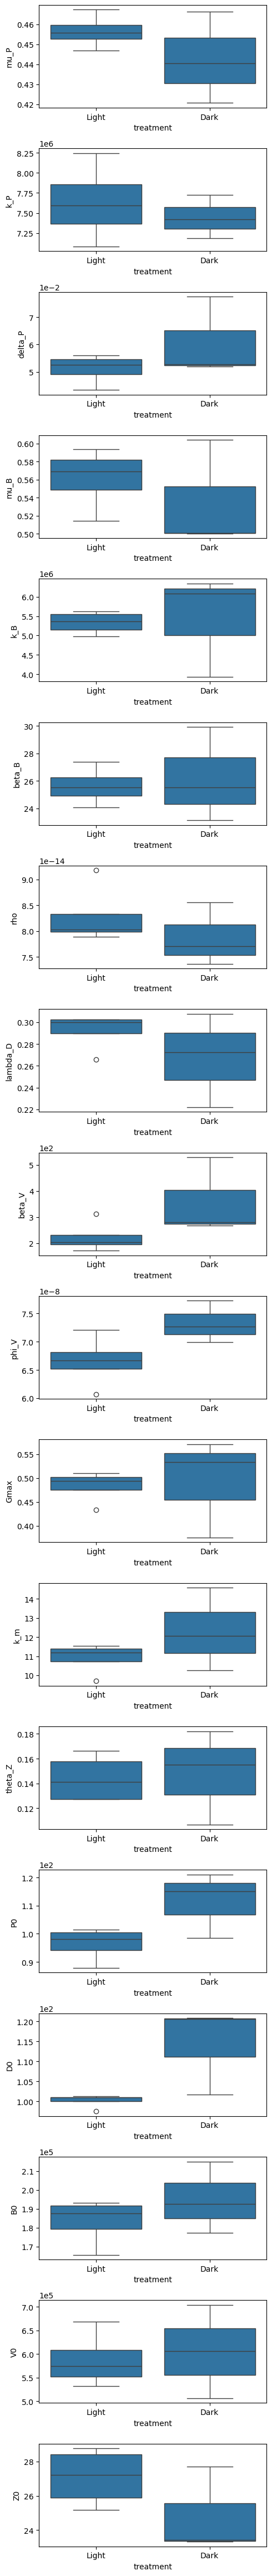

In [62]:
import seaborn as sns
f, ax = plt.subplots(figsize=(5,2.5*len(all_params_table.columns)-1), nrows=18)
for i in range(len(all_params_table.columns)-1):
    sns.boxplot(data=all_params_table.loc[all_params_table['treatment']!='Control'], x='treatment', y=all_params_table[all_params_table.columns[i]], ax = ax[i])
    ax[i].ticklabel_format(axis='y', style='sci', scilimits=(-2,2))
plt.tight_layout()

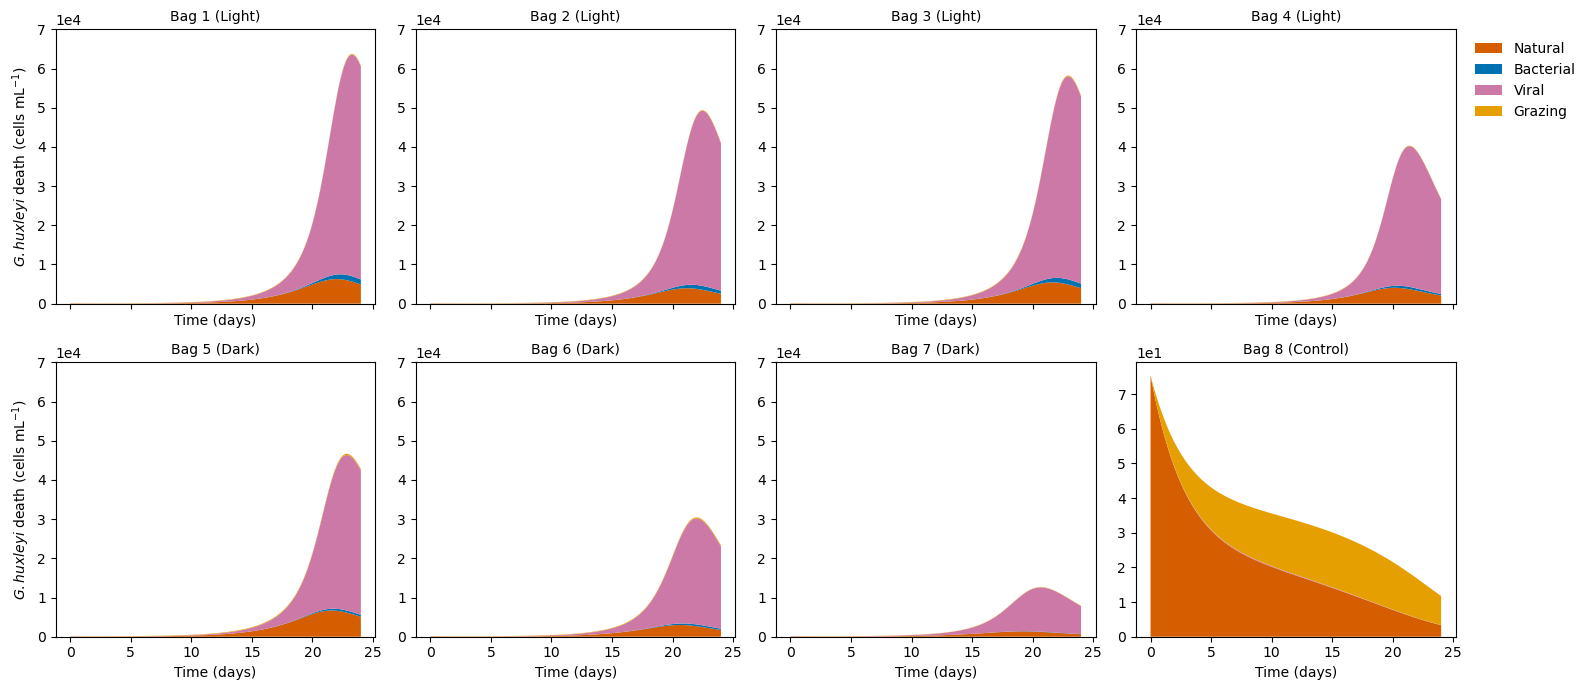

In [71]:
## Cell 8 -- per-bag death-signature plots (stackplot of D_nat/D_bact/D_vir/D_zoop) ##

colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']
TREATMENT_EDGE = {'Light': colors[3], 'Dark': colors[4], 'Control': colors[7]}

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
for ax, bag_id in zip(axes.flat, BAG_IDS):
    c = bag_results[bag_id]['curves']
    ax.stackplot(c['t'], c['D_nat'], c['D_bact'], c['D_vir'], c['D_zoop'],
                 labels=['Natural', 'Bacterial', 'Viral', 'Grazing'],
                 colors=[colors[5], colors[4], colors[6], colors[0]])
    treat = bag_results[bag_id]['treatment']
    ax.set_title(f'Bag {bag_id} ({treat})', fontsize=10)
    ax.set_xlabel('Time (days)')
    ax.ticklabel_format(style='sci', scilimits=(0, 0), axis='y')
axes[0, 0].set_ylabel(r'$\it{G. huxleyi}$ death (cells mL$^{-1}$)')
axes[1, 0].set_ylabel(r'$\it{G. huxleyi}$ death (cells mL$^{-1}$)')
axes[0, -1].legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
axes[0, 0].set_ylim(0, 7e4)
axes[1, 0].set_ylim(0, 7e4)
axes[0, 1].set_ylim(0, 7e4)
axes[1, 1].set_ylim(0, 7e4)
axes[0, 2].set_ylim(0, 7e4)
axes[1, 2].set_ylim(0, 7e4)
axes[0, 3].set_ylim(0, 7e4)
plt.tight_layout()
plt.savefig('figures/bag_death_signatures.png', dpi=300, bbox_inches='tight')
plt.show()


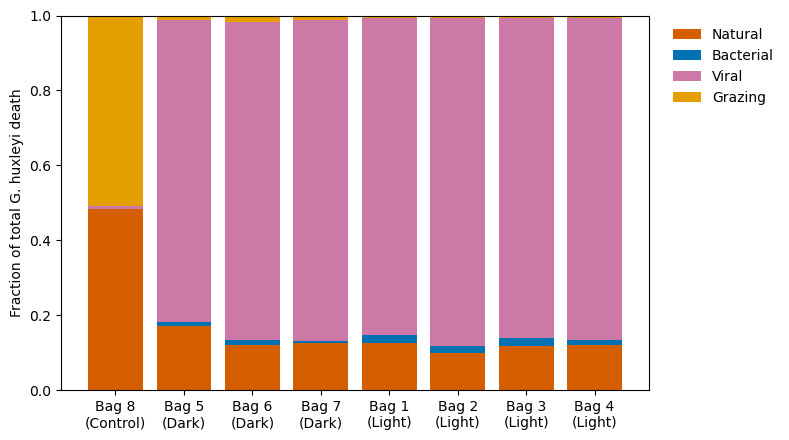


Death fractionation by treatment (mean across bags):
           Natural  Bacterial  Viral  Grazing
treatment                                    
Control      0.484      0.000  0.006    0.510
Dark         0.139      0.010  0.837    0.014
Light        0.116      0.018  0.859    0.007


In [11]:
## Cell 9 -- overall fractionation summary across all 8 bags ##

frac_df = pd.DataFrame({b: r['fractions'] for b, r in bag_results.items()}).T
frac_df.index.name = 'bag_id'
frac_df['treatment'] = [BAG_TREATMENT[b] for b in frac_df.index]
frac_df = frac_df.sort_values(['treatment', 'bag_id'])

fig, ax = plt.subplots(figsize=(8, 4.5))
bottom = np.zeros(len(frac_df))
pathway_colors = {'Natural': colors[5], 'Bacterial': colors[4], 'Viral': colors[6], 'Grazing': colors[0]}
x_labels = [f'Bag {b}\n({t})' for b, t in zip(frac_df.index, frac_df['treatment'])]

for pathway in ['Natural', 'Bacterial', 'Viral', 'Grazing']:
    ax.bar(x_labels, frac_df[pathway], bottom=bottom, label=pathway, color=pathway_colors[pathway])
    bottom += frac_df[pathway].values

ax.set_ylabel('Fraction of total G. huxleyi death')
ax.set_ylim(0, 1)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/bag_death_fractionation_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nDeath fractionation by treatment (mean across bags):')
print(frac_df.groupby('treatment')[['Natural', 'Bacterial', 'Viral', 'Grazing']].mean().round(3).to_string())


In [12]:
bag_results[1]['trace']

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

Saved trace for Bag 1 -> data/bag_fits/traces/bag_1_trace.nc
Saved trace for Bag 2 -> data/bag_fits/traces/bag_2_trace.nc
Saved trace for Bag 3 -> data/bag_fits/traces/bag_3_trace.nc
Saved trace for Bag 4 -> data/bag_fits/traces/bag_4_trace.nc
Saved trace for Bag 5 -> data/bag_fits/traces/bag_5_trace.nc
Saved trace for Bag 6 -> data/bag_fits/traces/bag_6_trace.nc
Saved trace for Bag 7 -> data/bag_fits/traces/bag_7_trace.nc
Saved trace for Bag 8 -> data/bag_fits/traces/bag_8_trace.nc


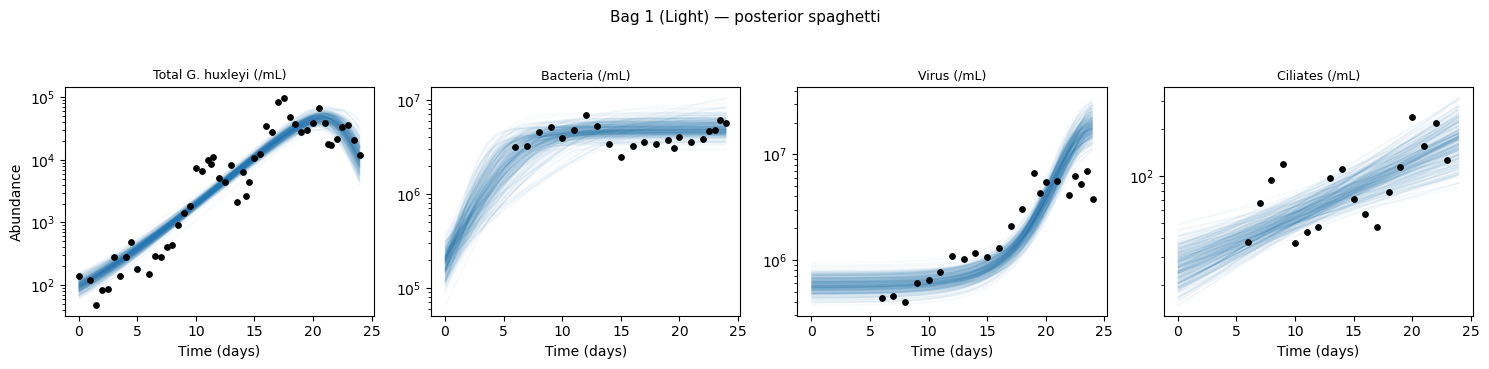

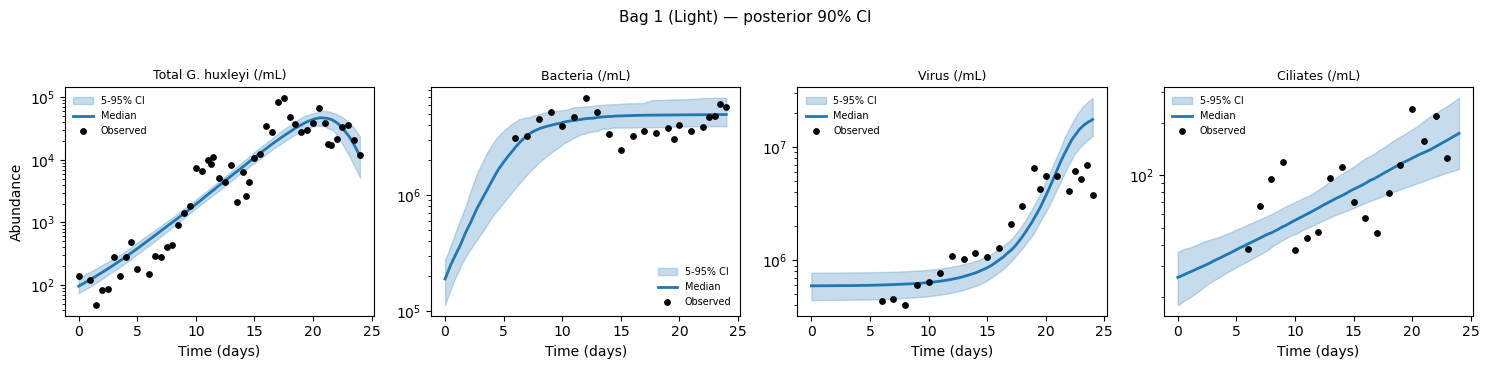

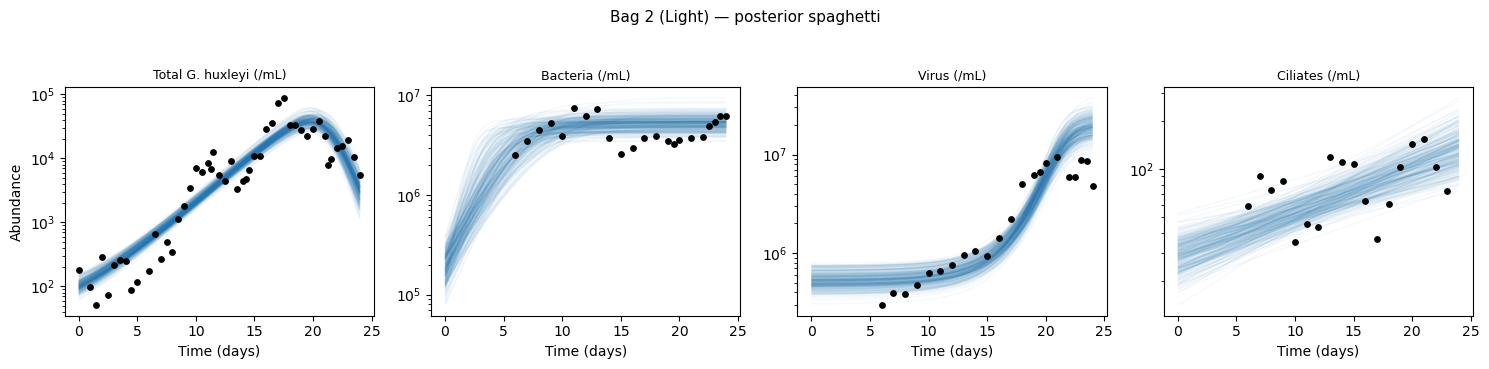

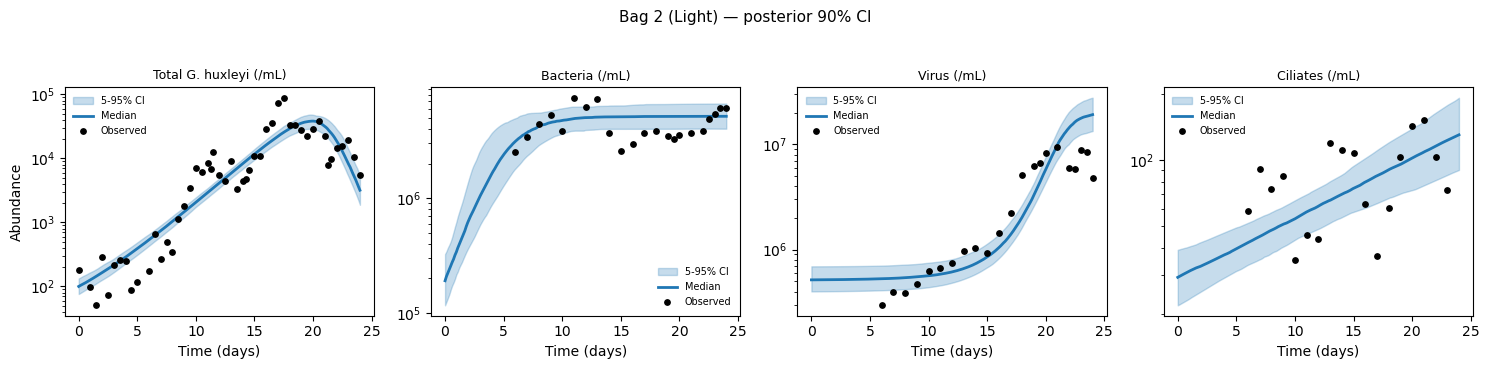

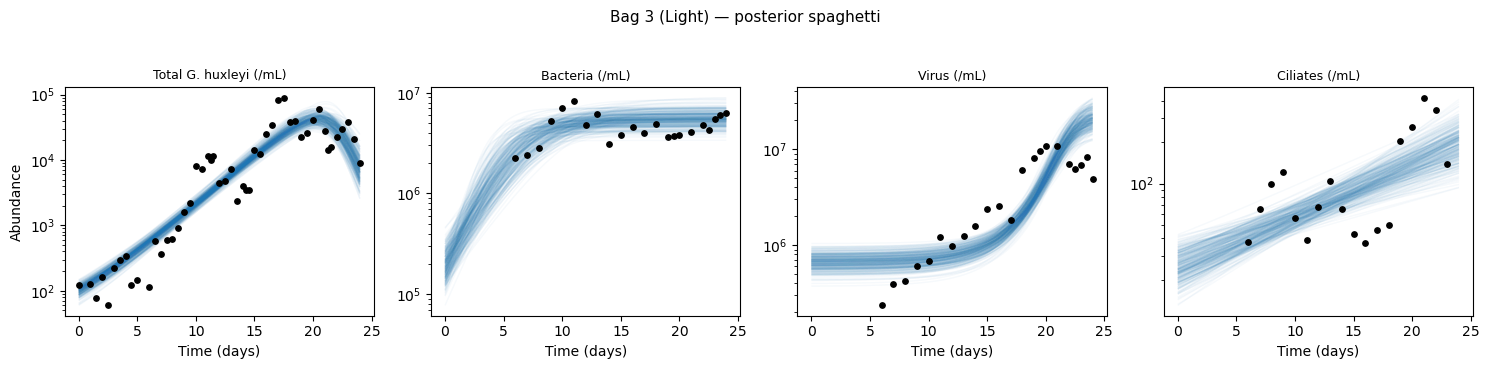

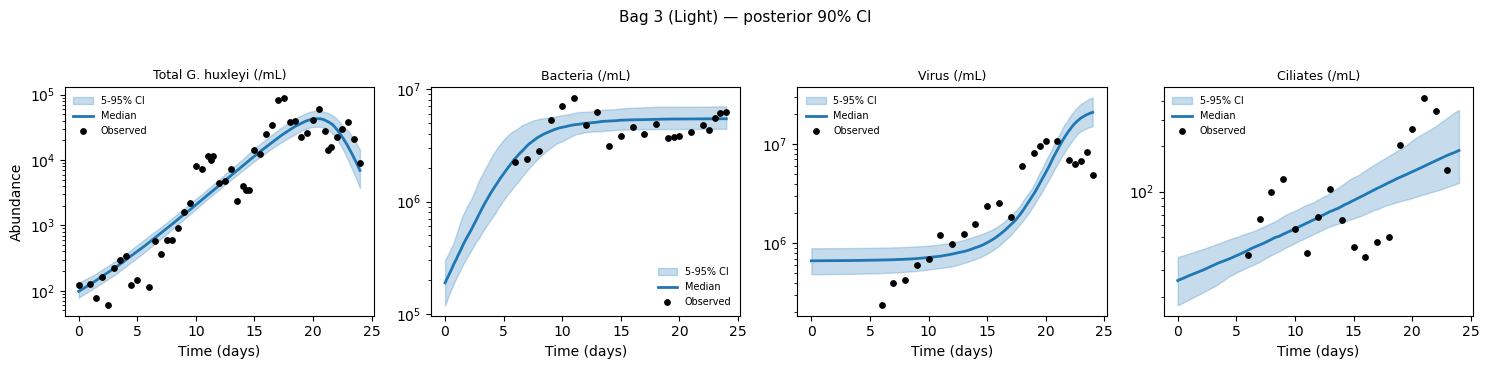

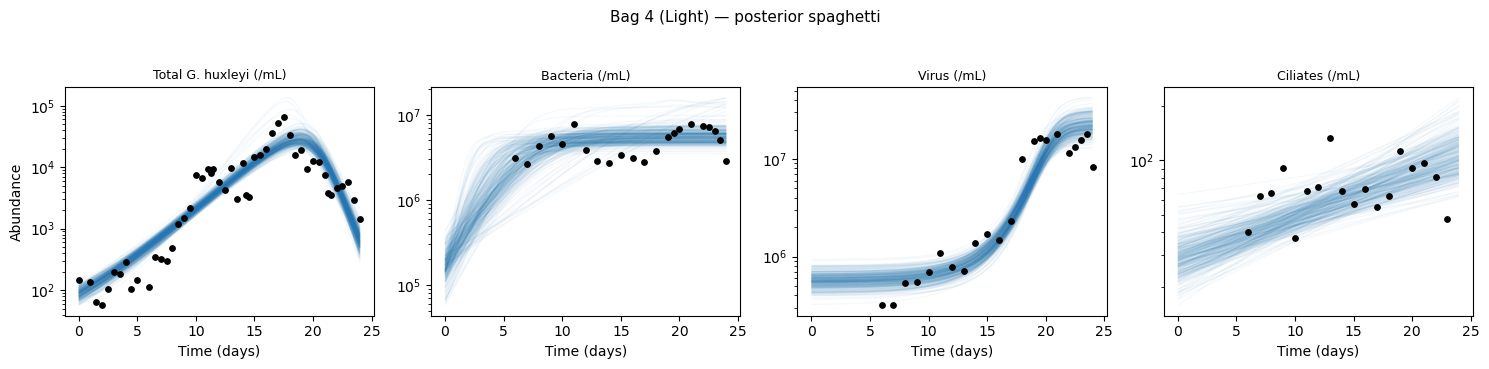

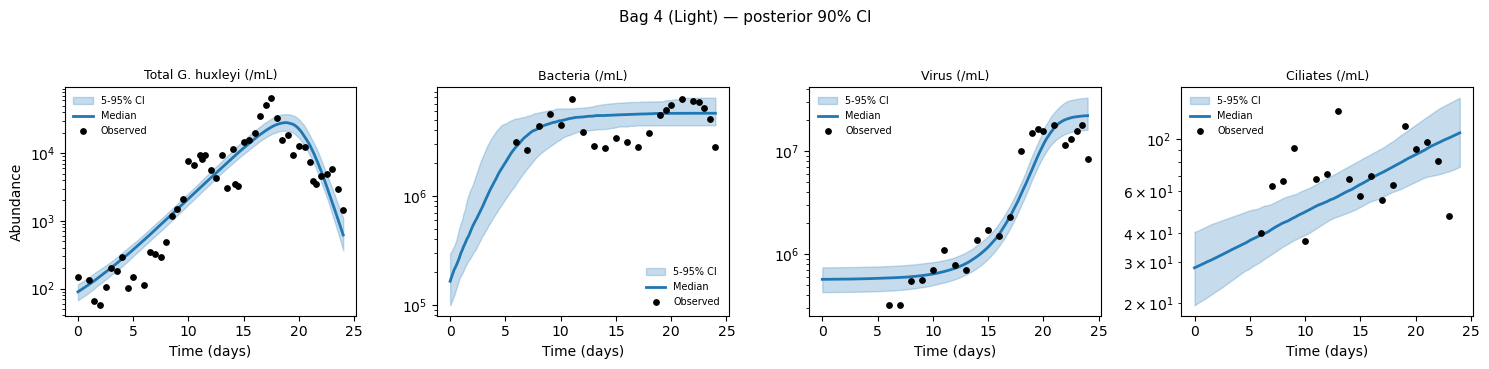

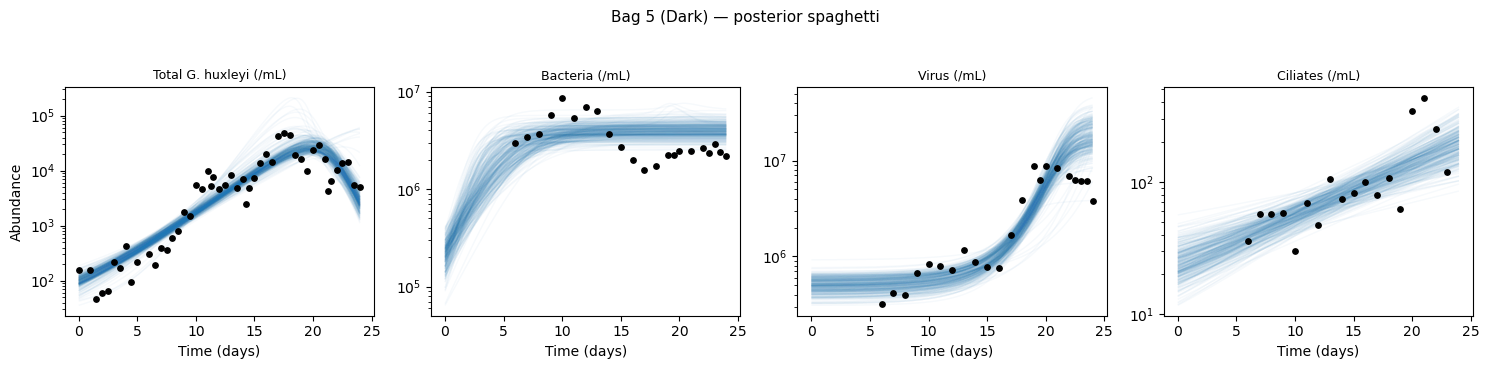

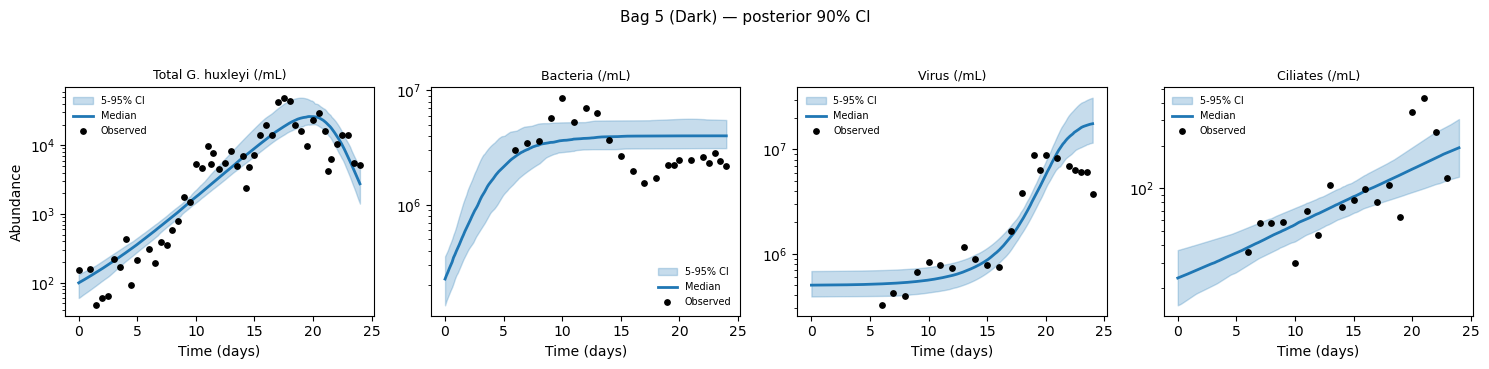

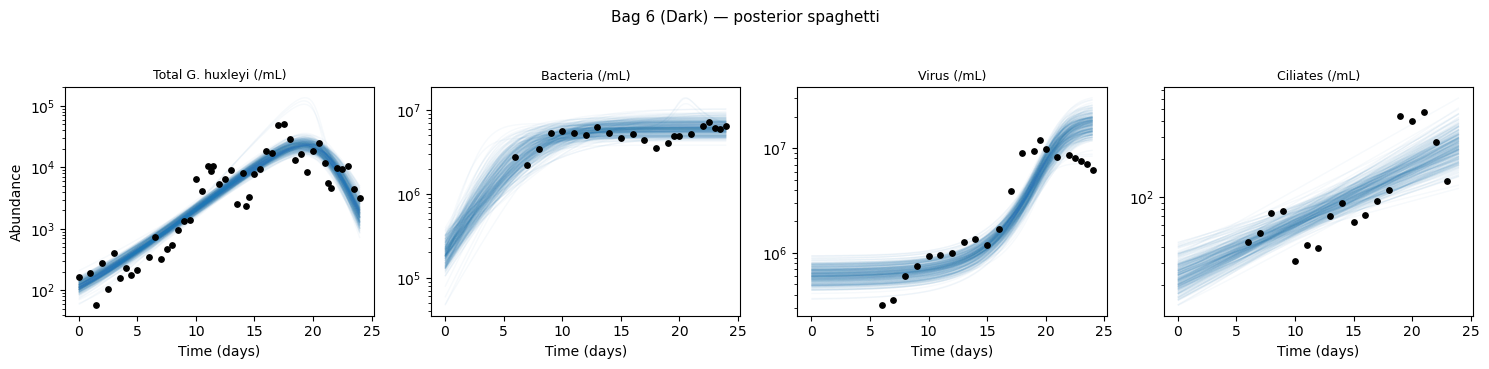

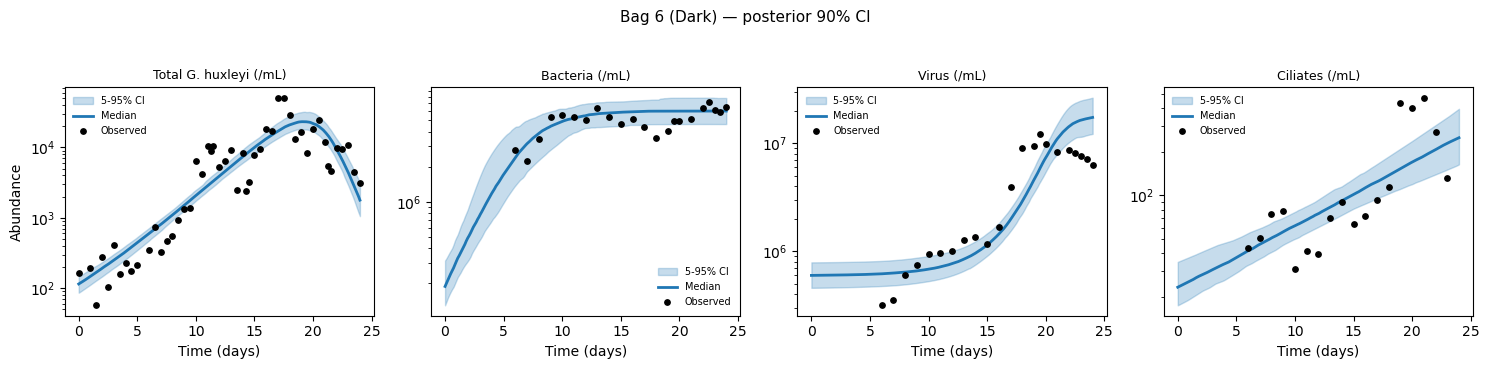

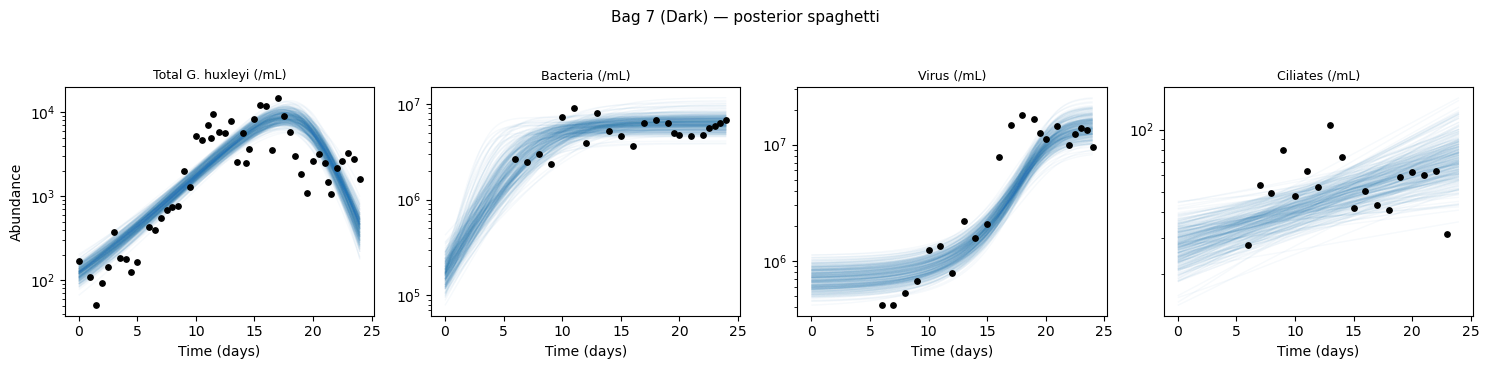

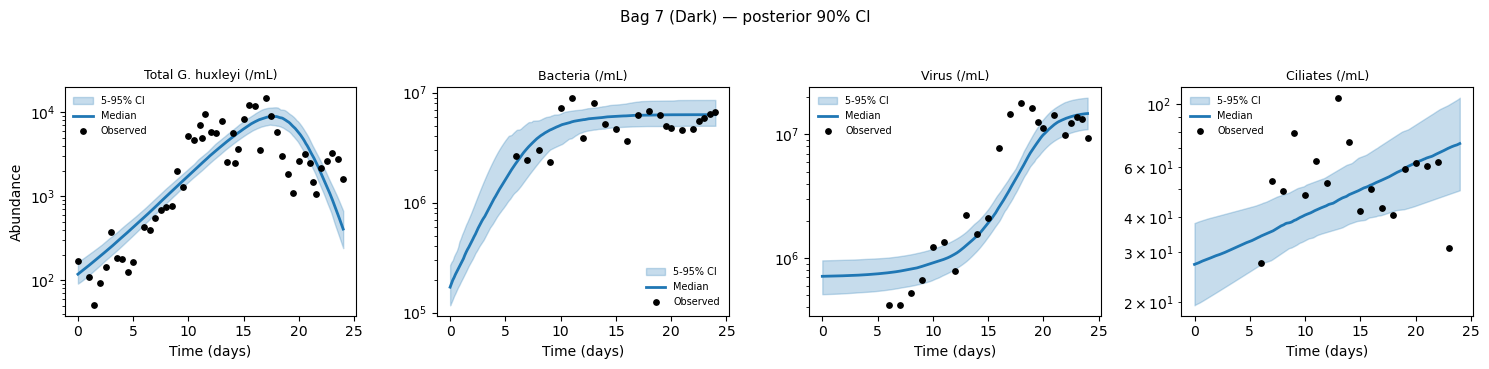

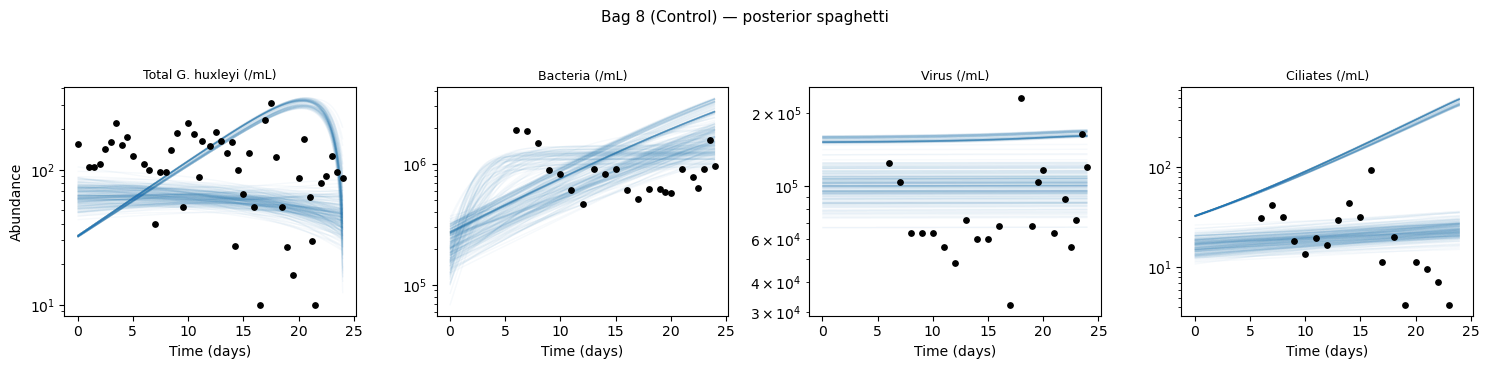

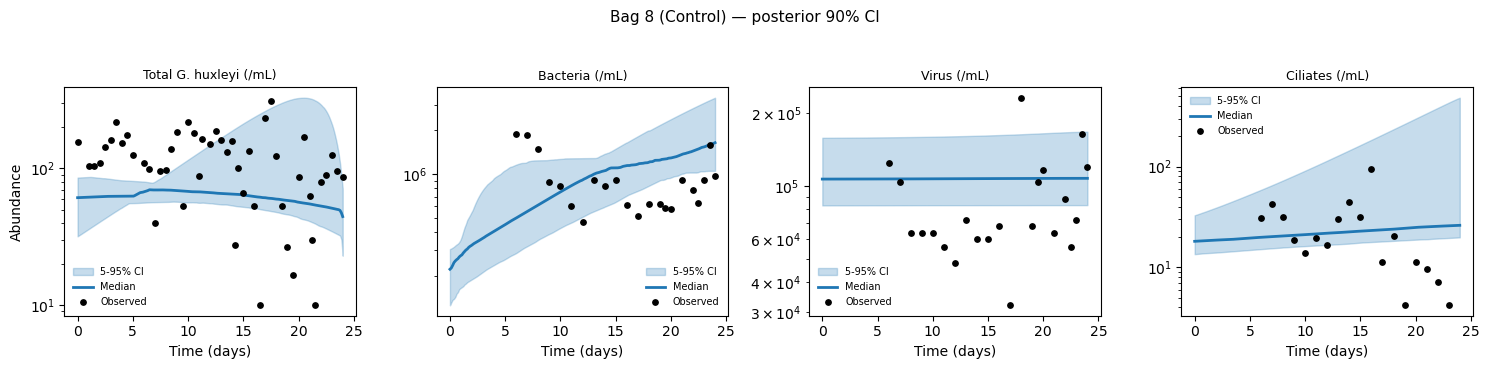

In [14]:
# %% [markdown]
# ## Save traces + per-bag posterior spaghetti/band plots
#
# Run this AFTER Cell 9 (the full sampling loop + fractionation summary)
# has completed and `bag_results` is populated in memory.
#
# Saves each bag's full trace to disk (Cell 6 only ever saved median_params,
# not the InferenceData itself -- so without this, a kernel restart means
# re-running all 8 fits from scratch), then generalizes MCMC_whole_env.py's
# eco_posterior_spaghetti/eco_posterior_bands (which hardcoded globals like
# ehux_live_time) to take a bag's `data` dict and `trace` explicitly, and
# loops over every bag.

# %%
## Cell 10 -- save every bag's full trace to disk ##

import arviz as az

os.makedirs('data/bag_fits/traces', exist_ok=True)
for bag_id, res in bag_results.items():
    res['trace'].to_netcdf(f'data/bag_fits/traces/bag_{bag_id}_trace.nc')
    print(f'Saved trace for Bag {bag_id} -> data/bag_fits/traces/bag_{bag_id}_trace.nc')

# To reload later without re-sampling:
#   trace = az.from_netcdf(f'data/bag_fits/traces/bag_{bag_id}_trace.nc')

# %%
## Cell 11 -- per-bag posterior spaghetti + confidence band plotting ##

from scipy.integrate import solve_ivp
from matplotlib.collections import LineCollection

STATE_COL = {'P': 0, 'D': 1, 'B': 2, 'V': 3, 'Z': 4}

def _posterior_1d(trace, name):
    post = trace.posterior.stack(draws=("chain", "draw"))
    return np.asarray(post[name].values).reshape(-1)

def _run_one_draw(theta, y0, t_eval, method_list=("LSODA", "BDF")):
    for method in method_list:
        try:
            sol = solve_ivp(fun=lambda t, y: general_case(t, y, theta),
                             t_span=(t_eval[0], t_eval[-1]), y0=y0, t_eval=t_eval,
                             method=method, rtol=1e-6, atol=1e-9)
            if sol.success and np.all(np.isfinite(sol.y)):
                return np.maximum(sol.y, 1.0)
        except Exception:
            continue
    return None

def _sample_draws(trace, n_samples, burn_in, seed):
    all_names = KINETIC_NAMES + IC_NAMES
    vals = {n: _posterior_1d(trace, n) for n in all_names}
    n_avail = len(vals['mu_P'])
    n_samples = min(n_samples, n_avail - burn_in)  # clamp instead of hard-asserting
    rng = np.random.default_rng(seed)
    idxs = rng.choice(np.arange(burn_in, n_avail), size=n_samples, replace=False)
    return vals, idxs

def _obs_panels(data):
    """Build the 4-stream panel spec from a single bag's data dict."""
    return [
        ('P', 'Total G. huxleyi (/mL)', data['ehux_live_time'], data['ehux_live_density']),
        ('B', 'Bacteria (/mL)',          data['bacteria_time'],  data['bacteria_density']),
        ('V', 'Virus (/mL)',             data['ehv_time'],       data['ehv_density']),
        ('Z', 'Ciliates (/mL)',          data['ciliate_time'],   data['ciliate_density']),
    ]

def eco_posterior_spaghetti_bag(trace, data, bag_id, n_samples=300, burn_in=0, seed=42,
                                 n_grid=200, alpha=0.04, save_path=None):
    obs_panels = _obs_panels(data)
    t_max = max(np.max(t) for _, _, t, _ in obs_panels)
    t_eval = np.linspace(0, t_max, n_grid)
    vals, idxs = _sample_draws(trace, n_samples, burn_in, seed)

    segments = {k: [] for k, *_ in obs_panels}
    for i in idxs:
        theta = [vals[n][i] for n in KINETIC_NAMES]
        y0    = [vals[n][i] for n in IC_NAMES]
        states = _run_one_draw(theta, y0, t_eval)
        if states is None:
            continue
        for key, *_ in obs_panels:
            segments[key].append(np.column_stack((t_eval, states[STATE_COL[key]]))[:, None, :])

    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharex=True)
    for ax, (key, label, t_obs, v_obs) in zip(axes, obs_panels):
        if segments[key]:
            arr = np.concatenate(segments[key], axis=1).transpose(1, 0, 2)
            ax.add_collection(LineCollection(arr, linewidths=1.0, alpha=alpha, color='C0'))
            ax.autoscale_view()
        ax.scatter(t_obs, v_obs, color='black', s=15, zorder=5)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Time (days)')
        ax.set_yscale('log')
    axes[0].set_ylabel('Abundance')
    treatment = BAG_TREATMENT.get(bag_id, '?')
    fig.suptitle(f'Bag {bag_id} ({treatment}) — posterior spaghetti', y=1.04, fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def eco_posterior_bands_bag(trace, data, bag_id, n_samples=200, burn_in=0, seed=42,
                             n_grid=200, lo=5, hi=95, save_path=None):
    obs_panels = _obs_panels(data)
    t_max = max(np.max(t) for _, _, t, _ in obs_panels)
    t_eval = np.linspace(0, t_max, n_grid)
    vals, idxs = _sample_draws(trace, n_samples, burn_in, seed)

    curves = {k: [] for k, *_ in obs_panels}
    for i in idxs:
        theta = [vals[n][i] for n in KINETIC_NAMES]
        y0    = [vals[n][i] for n in IC_NAMES]
        states = _run_one_draw(theta, y0, t_eval)
        if states is None:
            continue
        for key, *_ in obs_panels:
            curves[key].append(states[STATE_COL[key]])

    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharex=True)
    for ax, (key, label, t_obs, v_obs) in zip(axes, obs_panels):
        if curves[key]:
            arr = np.array(curves[key])
            p_lo, p_med, p_hi = np.percentile(arr, [lo, 50, hi], axis=0)
            ax.fill_between(t_eval, p_lo, p_hi, alpha=0.25, color='C0', label=f'{lo}-{hi}% CI')
            ax.plot(t_eval, p_med, color='C0', lw=2, label='Median')
        ax.scatter(t_obs, v_obs, color='black', s=15, zorder=5, label='Observed')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Time (days)')
        ax.set_yscale('log')
        ax.legend(fontsize=7, frameon=False)
    axes[0].set_ylabel('Abundance')
    treatment = BAG_TREATMENT.get(bag_id, '?')
    fig.suptitle(f'Bag {bag_id} ({treatment}) — posterior 90% CI', y=1.04, fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# %%
## Cell 12 -- loop over every bag, generate + save both plot types ##

os.makedirs('figures/bags', exist_ok=True)

for bag_id in BAG_IDS:
    res = bag_results[bag_id]
    data, trace = res['data'], res['trace']

    eco_posterior_spaghetti_bag(
        trace, data, bag_id, n_samples=300,
        save_path=f'figures/bags/bag_{bag_id}_spaghetti.png',
    )
    eco_posterior_bands_bag(
        trace, data, bag_id, n_samples=200,
        save_path=f'figures/bags/bag_{bag_id}_bands.png',
    )
